In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data.csv")

In [3]:
print(df.head())
print("")
print(df.shape)

   Age  Sex  ChestPain  RestBP  Cholesterol  MaxHR  ExerciseAngina  Target
0   63    1          3     145          233    150               0       1
1   37    1          2     130          250    187               0       1
2   41    0          1     130          204    172               0       1
3   56    1          1     120          236    178               0       1
4   57    0          0     120          354    163               1       0

(20, 8)


In [4]:
x = df[["Age", "Sex", "ChestPain", "RestBP", "Cholesterol", "MaxHR","ExerciseAngina"]].values
y = df["Target"].values

In [5]:
print(x.shape)
print(y.shape)

(20, 7)
(20,)


In [6]:
indices = np.random.permutation(len(x))

x = x[indices]
y = y[indices]

split = int(0.8 * len(x))

x_train = x[:split]
y_train = y[:split]

x_test = x[split:]
y_test = y[split:]

In [7]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (16, 7)
y_train shape: (16,)
x_test shape: (4, 7)
y_test shape: (4,)


In [8]:
mu = np.mean(x_train, axis=0)
sigma = np.std(x_train, axis=0)

sigma[sigma == 0] = 1

x_train = (x_train - mu) / sigma
x_test = (x_test - mu) / sigma

In [9]:
w = np.zeros(x_train.shape[1])
b = 0

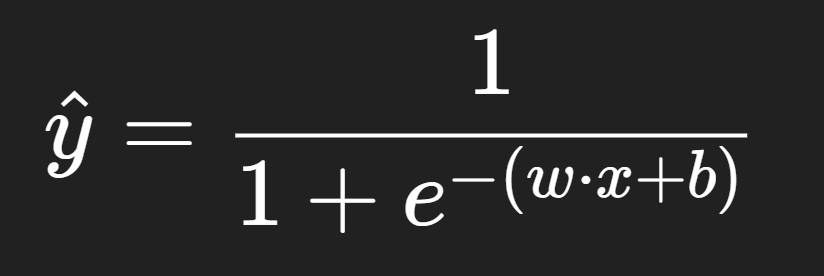

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [11]:
def predict(w, x, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

In [12]:
print(predict(w, x_train[:2], b))

[0.5 0.5]


In [13]:
def compute_cost(w, x, b, y):
    y_pred = predict(w, x, b)
    m = len(x)

    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    cost = (-1 / m) * np.sum(
        (y * np.log(y_pred)) + ((1 - y) * np.log(1 - y_pred))
    )

    return cost

In [14]:
def compute_gradient(w, x, b, y):
    m = len(x)
    y_pred = predict(w, x, b)

    error = y_pred - y

    dj_dw = (1 / m) * np.dot(x.T, error)
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db

In [15]:
alpha = 0.01
iterations = 1000
tolerance = 1e-4

cost_history = []
previous_cost = float('inf')

for i in range(iterations):

    dj_dw, dj_db = compute_gradient(w, x_train, b, y_train)

    w = w - (alpha * dj_dw)
    b = b - (alpha * dj_db)

    cost = compute_cost(w, x_train, b, y_train)
    cost_history.append(cost)

    if previous_cost != float('inf'):
        if abs(previous_cost - cost) / previous_cost < tolerance:
            print(f"Converged after {i} iterations")
            break

    previous_cost = cost

    if i % 100 == 0:
        print(f"Iteration {i}, Cost: {cost:.5f}")


Iteration 0, Cost: 0.69110
Iteration 100, Cost: 0.53955
Iteration 200, Cost: 0.45312
Iteration 300, Cost: 0.39875
Iteration 400, Cost: 0.36177
Iteration 500, Cost: 0.33510
Iteration 600, Cost: 0.31498
Iteration 700, Cost: 0.29927
Iteration 800, Cost: 0.28665
Iteration 900, Cost: 0.27627


In [16]:
print(predict(w, x_test, b))

[0.89233538 0.85060673 0.86267811 0.90488924]


In [17]:
def classify(w, x, b):
    probs = predict(w, x, b)
    return (probs >= 0.5).astype(int)

In [18]:
y_pred = classify(w, x_test, b)

In [19]:
print("Predictions:", y_pred)
print("Actual:", y_test)

Predictions: [1 1 1 1]
Actual: [1 1 1 1]


In [20]:
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy * 100}%")

Accuracy: 100.0%


In [21]:
probs = predict(w, x_test, b)

for i in range(len(y_test)):
    print(f"Prob: {probs[i]:.2f}, Pred: {y_pred[i]}, Actual: {y_test[i]}")

Prob: 0.89, Pred: 1, Actual: 1
Prob: 0.85, Pred: 1, Actual: 1
Prob: 0.86, Pred: 1, Actual: 1
Prob: 0.90, Pred: 1, Actual: 1


#### Confusion Matrix
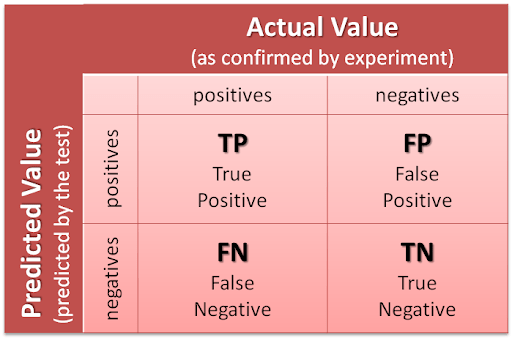

In [22]:
tp = np.sum((y_pred == 1) & (y_test == 1))
tn = np.sum((y_pred == 0) & (y_test == 0))
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))

print("\nConfusion Matrix:") 
print(f"TP (True Positive): {tp}") 
print(f"TN (True Negative): {tn}") 
print(f"FP (False Positive): {fp}") 
print(f"FN (False Negative): {fn}")


Confusion Matrix:
TP (True Positive): 4
TN (True Negative): 0
FP (False Positive): 0
FN (False Negative): 0


In [24]:
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 =  2 * ((precision * recall) / (precision + recall))


print(f"Out of {np.sum(y_pred == 1)} I said have disease, {precision:.2f} actually had it (Precision).")
print(f"Out of {np.sum(y_test == 1)} actual disease cases, {recall:.2f} were detected (Recall).")
print(f"F1 Score: {f1:.2f} (Balance of Precision and Recall).")

Out of 4 I said have disease, 1.00 actually had it (Precision).
Out of 4 actual disease cases, 1.00 were detected (Recall).
F1 Score: 1.00 (Balance of Precision and Recall).


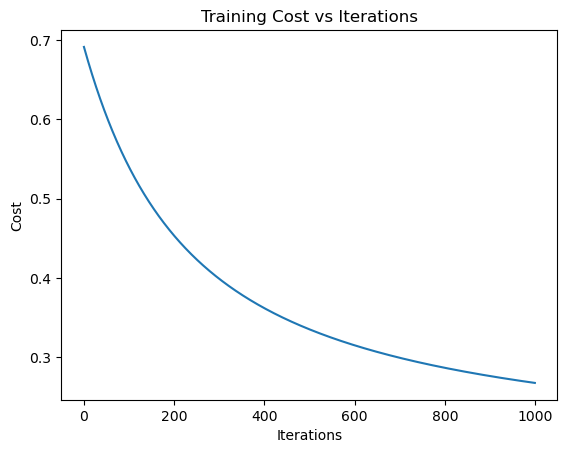

In [29]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Cost vs Iterations")
plt.show()

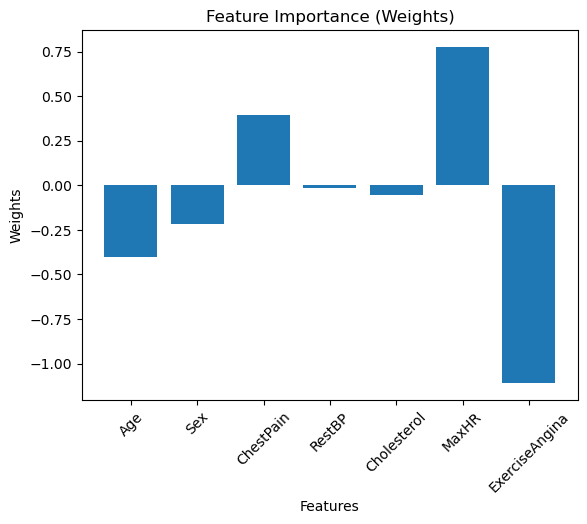

In [30]:
features = ["Age", "Sex", "ChestPain", "RestBP", "Cholesterol", "MaxHR", "ExerciseAngina"]

plt.bar(features, w)
plt.title("Feature Importance (Weights)")
plt.xlabel("Features")
plt.ylabel("Weights")
plt.xticks(rotation=45)
plt.show()

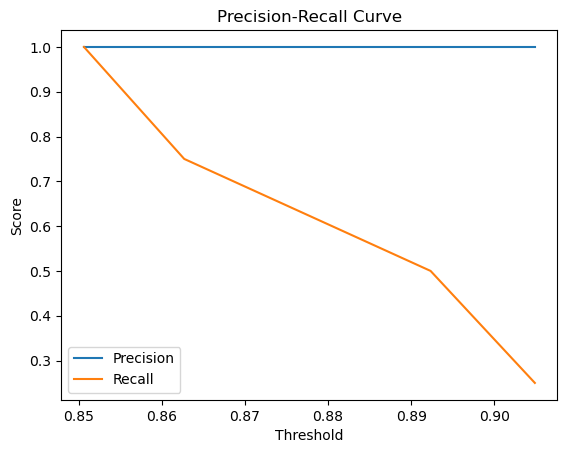

In [28]:
from sklearn.metrics import precision_recall_curve

# Get prediction probabilities (you already have `probs`)
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Plot
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()